# SecureFlow Analytics - Funnel Analysis
## Phase 2: Conversion Funnels & Drop-off Analysis

**Goal:** Identify where users drop off in the conversion journey and why.

**Key Questions:**
1. What's the conversion rate at each funnel stage?
2. Where do users drop off most?
3. How do funnels differ by segment (country, channel, experiment)?
4. How long does it take users to convert?

---

In [12]:
import sys
sys.path.append('../src')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Custom modules
import config
from analytics.funnel_analysis import * 
from utils import *
#(
#    calculate_funnel,
#    calculate_time_to_convert,
#    calculate_drop_off_reasons
#)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Imports successful")

✅ Imports successful


In [13]:
# Connect to DuckDB
con = duckdb.connect()
print(f"📊 DuckDB connection established")

📊 DuckDB connection established


---
## 1. Overall Conversion Funnel

**Funnel Stages:**
1. Sign Up
2. App Install
3. First Scan
4. Protection Enabled
5. Subscription

In [14]:
# Check actual event types
event_types = execute_query(con, f"""
    SELECT event_type, COUNT(*) as count
    FROM read_parquet('{config.EVENTS_FILE}')
    GROUP BY event_type
    ORDER BY count DESC
""")
display(event_types)

,event_type,count
0,app_open,6408135
1,scan_started,3494967
2,scan_completed,2916551
3,onboarding_step_completed,2913110
4,settings_changed,2330004
5,help_viewed,2325892
6,notification_clicked,2039552
7,threat_detected,1458103
8,threat_resolved,1457181
9,upgrade_clicked,1455219


In [ ]:
# Funnel 1: Onboarding
onboarding_funnel = [
    ('App Open', 'app_open'),
    ('Onboarding Started', 'onboarding_step_completed'),
    ('First Scan', 'scan_completed'),
    ('Settings Changed', 'settings_changed'),
    ('Upgrade Clicked', 'upgrade_clicked'),
]

engagement_funnel = [
    ('App Open', 'app_open'),
    ('First Scan', 'scan_completed'),
    ('Threat Resolved', 'threat_resolved'),
    ('Feature Discovered', 'feature_discovered'),
    ('Share Clicked', 'share_clicked'),
]
conversion_funnel = [
    ('App Open', 'app_open'),
    ('Scan Completed', 'scan_completed'),
    ('Threat Detected', 'threat_detected'),
    ('Help Viewed', 'help_viewed'),
    ('Upgrade Clicked', 'upgrade_clicked'),
]

security_workflow_funnel = [
    ('Scan Started', 'scan_started'),
    ('Scan Completed', 'scan_completed'),
    ('Threat Detected', 'threat_detected'),
    ('Threat Resolved', 'threat_resolved'),
]

# Security Workflow funnel

onboarding_funnel, onboarding_steps = calculate_funnel(con, onboarding_funnel)
print("\n📊 Onboarding Funnel:")
display(onboarding_funnel)
#display(onboarding_steps)
print("--------------------------------------------------")

engagement_funnel, engagement_steps = calculate_funnel(con, engagement_funnel)
print("\n📊 Engagement Funnel:")
display(engagement_funnel)
print("--------------------------------------------------")

conversion_funnel, conversion_steps = calculate_funnel(con, conversion_funnel)
print("\n📊 Conversion Funnel:")
display(conversion_funnel)
print("--------------------------------------------------")

security_workflow_funnel, security_workflow_steps = calculate_funnel(con, security_workflow_funnel)
print("\n📊 Security Workflow Funnel:")
display(security_workflow_funnel)
print("--------------------------------------------------")


📊 Onboarding Funnel:


,step_0_users,step_1_users,step_2_users,step_3_users,step_4_users,step_0_to_1_rate,step_1_to_2_rate,step_1_to_2_incremental,step_2_to_3_rate,step_2_to_3_incremental,step_3_to_4_rate,step_3_to_4_incremental
0,49591,48469,48470,48088,47180,97.74,97.74,100.0,96.97,99.21,95.14,98.11


--------------------------------------------------

📊 Engagement Funnel:


,step_0_users,step_1_users,step_2_users,step_3_users,step_4_users,step_0_to_1_rate,step_1_to_2_rate,step_1_to_2_incremental,step_2_to_3_rate,step_2_to_3_incremental,step_3_to_4_rate,step_3_to_4_incremental
0,49591,48470,47132,47126,45863,97.74,95.04,97.24,95.03,99.99,92.48,97.32


--------------------------------------------------

📊 Conversion Funnel:


,step_0_users,step_1_users,step_2_users,step_3_users,step_4_users,step_0_to_1_rate,step_1_to_2_rate,step_1_to_2_incremental,step_2_to_3_rate,step_2_to_3_incremental,step_3_to_4_rate,step_3_to_4_incremental
0,49591,48470,47152,48094,47180,97.74,95.08,97.28,96.98,102.0,95.14,98.1


--------------------------------------------------

📊 Security Workflow Funnel:


,step_0_users,step_1_users,step_2_users,step_3_users,step_0_to_1_rate,step_1_to_2_rate,step_1_to_2_incremental,step_2_to_3_rate,step_2_to_3_incremental
0,49010,48073,46860,46892,98.09,95.61,97.48,95.68,100.07


--------------------------------------------------


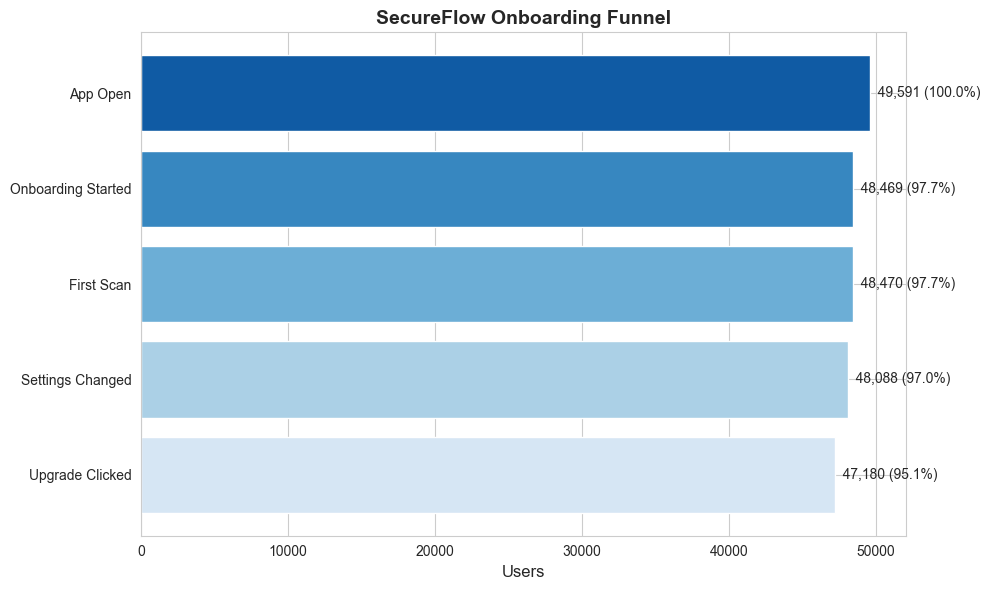


📉 Drop-off Analysis:
App Open → Onboarding Started: 1,122 users (2.3% drop-off)
Onboarding Started → First Scan: -1 users (-0.0% drop-off)
First Scan → Settings Changed: 382 users (0.8% drop-off)
Settings Changed → Upgrade Clicked: 908 users (1.9% drop-off)


In [22]:
# Visualize funnel
fig, ax = plt.subplots(figsize=(10, 6))

step_cols = [col for col in onboarding_funnel.columns if col.endswith('_users')]
step_values = onboarding_funnel[step_cols].values[0]
step_labels = [onboarding_steps[col] for col in step_cols]

# Funnel chart
colors = sns.color_palette('Blues_r', len(step_values))
y_pos = np.arange(len(step_labels))

ax.barh(y_pos, step_values, color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(step_labels)
ax.invert_yaxis()
ax.set_xlabel('Users', fontsize=12)
ax.set_title('SecureFlow Onboarding Funnel', fontsize=14, fontweight='bold')

# Add values and conversion rates
for i, (value, label) in enumerate(zip(step_values, step_labels)):
    pct = (value / step_values[0] * 100) if step_values[0] > 0 else 0
    ax.text(value, i, f'  {int(value):,} ({pct:.1f}%)', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Calculate drop-off percentages
print("\n📉 Drop-off Analysis:")
for i in range(len(step_values) - 1):
    drop_off = step_values[i] - step_values[i+1]
    drop_pct = (drop_off / step_values[i] * 100) if step_values[i] > 0 else 0
    print(f"{step_labels[i]} → {step_labels[i+1]}: {int(drop_off):,} users ({drop_pct:.1f}% drop-off)")

---
## 2. Funnel by Country

Does conversion differ by geography?

In [27]:
conversion_steps

{'step_0_users': 'App Open',
 'step_1_users': 'Scan Completed',
 'step_2_users': 'Threat Detected',
 'step_3_users': 'Help Viewed',
 'step_4_users': 'Upgrade Clicked'}

In [28]:
# Calculate funnel by country
country_funnel, _ = calculate_funnel(con, conversion_steps, segment_by='country')
print("\n🌍 Conversion Funnel by Country:")
display(country_funnel.sort_values('step_0_users', ascending=False))

ValueError: too many values to unpack (expected 2)

In [ ]:
# Compare Sign Up → Subscription rate by country
fig, ax = plt.subplots(figsize=(10, 6))

country_funnel_sorted = country_funnel.sort_values('step_0_to_4_rate', ascending=False)

ax.barh(country_funnel_sorted['country'], country_funnel_sorted['step_0_to_4_rate'])
ax.set_xlabel('Sign Up → Subscription Rate (%)', fontsize=12)
ax.set_title('Conversion Rate by Country', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (country, rate) in enumerate(zip(country_funnel_sorted['country'], country_funnel_sorted['step_0_to_4_rate'])):
    ax.text(rate, i, f' {rate:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 3. Funnel by Acquisition Channel

Which channels bring the highest quality users?

In [ ]:
# Calculate funnel by channel
channel_funnel, _ = calculate_funnel(con, funnel_steps, segment_by='acquisition_channel')
print("\n📱 Conversion Funnel by Channel:")
display(channel_funnel.sort_values('step_0_users', ascending=False))

In [ ]:
# Heatmap: Channel performance across stages
fig, ax = plt.subplots(figsize=(12, 6))

rate_cols = [col for col in channel_funnel.columns if col.endswith('_rate')]
heatmap_data = channel_funnel.set_index('acquisition_channel')[rate_cols]
heatmap_data.columns = ['Install', 'Scan', 'Protection', 'Subscribe']

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', cbar_kws={'label': 'Conversion Rate (%)'}, ax=ax)
ax.set_title('Conversion Rates by Channel & Stage', fontsize=14, fontweight='bold')
ax.set_xlabel('Funnel Stage', fontsize=12)
ax.set_ylabel('Acquisition Channel', fontsize=12)

plt.tight_layout()
plt.show()

---
## 4. Time to Convert

How long does it take users to move through the funnel?

In [ ]:
# Time from sign up to first scan
time_to_scan = calculate_time_to_convert(con, 'sign_up', 'scan_completed')
print("\n⏱️ Time from Sign Up to First Scan:")
display(time_to_scan)

# Time from sign up to subscription
time_to_sub = calculate_time_to_convert(con, 'sign_up', 'subscription_started')
print("\n⏱️ Time from Sign Up to Subscription:")
display(time_to_sub)

In [ ]:
# Compare time to scan by channel
time_by_channel = calculate_time_to_convert(con, 'sign_up', 'scan_completed', segment_by='acquisition_channel')
print("\n⏱️ Time to First Scan by Channel:")
display(time_by_channel.sort_values('median_days'))

---
## 5. Drop-off Characteristics

Who are the users dropping off?

In [ ]:
# Analyze drop-off patterns
drop_offs = calculate_drop_off_reasons(con, funnel_steps)
print("\n🔍 Top Segments with High Drop-off:")
display(drop_offs.head(20))

---
## 6. Experiment Impact on Funnel

How did experiments affect conversion?

In [ ]:
# Get users in exp_001 (new onboarding)
query = """
WITH exp_users AS (
    SELECT user_id, variant
    FROM read_parquet('G:/My Drive/SecureFlow_Analytics/data/raw/experiment_assignments.parquet')
    WHERE experiment_id = 'exp_001'
),
funnel_events AS (
    SELECT 
        e.user_id,
        eu.variant,
        e.event_type
    FROM read_parquet('G:/My Drive/SecureFlow_Analytics/data/raw/events.parquet') e
    INNER JOIN exp_users eu ON e.user_id = eu.user_id
    WHERE e.event_type IN ('sign_up', 'app_install', 'scan_completed', 'protection_enabled', 'subscription_started')
)
SELECT 
    variant,
    COUNT(DISTINCT CASE WHEN event_type = 'sign_up' THEN user_id END) as sign_ups,
    COUNT(DISTINCT CASE WHEN event_type = 'app_install' THEN user_id END) as installs,
    COUNT(DISTINCT CASE WHEN event_type = 'scan_completed' THEN user_id END) as scans,
    COUNT(DISTINCT CASE WHEN event_type = 'protection_enabled' THEN user_id END) as protection,
    COUNT(DISTINCT CASE WHEN event_type = 'subscription_started' THEN user_id END) as subscriptions
FROM funnel_events
GROUP BY variant
"""

exp_funnel = con.execute(query).df()

# Calculate rates
for col in ['installs', 'scans', 'protection', 'subscriptions']:
    exp_funnel[f'{col}_rate'] = (exp_funnel[col] / exp_funnel['sign_ups'] * 100).round(2)

print("\n🧪 exp_001 (New Onboarding) - Funnel Comparison:")
display(exp_funnel)

In [ ]:
# Visualize experiment impact
fig, ax = plt.subplots(figsize=(10, 6))

stages = ['Install', 'Scan', 'Protection', 'Subscribe']
control_rates = exp_funnel[exp_funnel['variant'] == 'control'][[f'{s.lower()}s_rate' for s in stages]].values[0]
treatment_rates = exp_funnel[exp_funnel['variant'] == 'treatment'][[f'{s.lower()}s_rate' for s in stages]].values[0]

x = np.arange(len(stages))
width = 0.35

ax.bar(x - width/2, control_rates, width, label='Control', color='#ff7f0e')
ax.bar(x + width/2, treatment_rates, width, label='Treatment', color='#2ca02c')

ax.set_xlabel('Funnel Stage', fontsize=12)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('exp_001: New Onboarding Impact on Funnel', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate lift
print("\n📈 Lift from Treatment:")
for i, stage in enumerate(stages):
    lift = ((treatment_rates[i] - control_rates[i]) / control_rates[i] * 100)
    print(f"{stage}: {lift:+.1f}% lift")

---
## Key Insights

**Summary of findings:**
1. Biggest drop-off stage?
2. Best performing channel?
3. Experiment impact?
4. Recommendations?

In [ ]:
# Close connection
con.close()
print("\n✅ Analysis complete")